In [2]:

import segment_anything
from PIL import Image
import cv2
import numpy as np
from PIL import Image
from surya.foundation import FoundationPredictor
from surya.layout import LayoutPredictor
from surya.settings import settings

image = Image.open("../../assets/images/IMG_20260304_223308_102.jpg")
layout_predictor = LayoutPredictor(FoundationPredictor(checkpoint=settings.LAYOUT_MODEL_CHECKPOINT))

# layout_predictions is a list of dicts, one per image
layout_predictions = layout_predictor([image])
#model = segment_anything.build_sam_vit_b(checkpoint='../../../weights/sam_vit_b_01ec64.pth') #

# from segment_anything import SamPredictor, sam_model_registry
# sam = sam_model_registry["vit_b"](checkpoint='../../../weights/sam_vit_b_01ec64.pth')
# predictor = SamPredictor(sam)
# image = cv2.imread("../../assets/images/IMG_20260304_223308_102.jpg")
# predictor.set_image(image)
# masks, _, _ = predictor.predict(point_coords=np.array([[500, 500], [501, 500]]), point_labels=np.array([1, 1]), multimask_output=True,)

# pipeline = PPStructureV3(use_doc_unwarping=True) # Use use_doc_unwarping to enable/disable document unwarping module
# output = pipeline.predict("../../assets/images/IMG_20260304_223308_102.jpg")
# for res in output:
#     res.print() ## Print the structured prediction output
#     res.save_to_json(save_path="output") ## Save the current image's structured result in JSON format
#     res.save_to_markdown(save_path="output") ## Save the current image's result in Markdown format

# model = LayoutDetection(model_name="PP-DocLayout_plus-L")
# output = model.predict("../../assets/images/IMG_20260304_223308_102.jpg", batch_size=1, layout_nms=True)
# for res in output:
#     res.print()
#     res.save_to_img(save_path="./output/")
#     res.save_to_json(save_path="./output/res.json")

Recognizing Layout: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


In [6]:
layout_predictions[0]

LayoutResult(bboxes=[LayoutBox(polygon=[[1011.375, 204.0], [1436.625, 164.0], [1436.625, 204.0], [1011.375, 244.0]], confidence=0.7861789464950562, label='PageHeader', position=0, top_k={'PageHeader': 0.7861789464950562, 'Text': 0.1409541219472885, 'SectionHeader': 0.05519842356443405, 'Picture': 0.010210682637989521, 'Figure': 0.005638873670250177}, bbox=[1011.375, 164.0, 1436.625, 244.0]), LayoutBox(polygon=[[108.0, 466.0], [1485.0, 330.0], [1503.0, 582.0], [126.0, 718.0]], confidence=0.9773157835006714, label='Text', position=1, top_k={'Text': 0.9773157835006714, 'Picture': 0.01483975537121296, 'PageHeader': 0.006186130456626415, 'Figure': 0.0010419144527986646, 'ListItem': 0.00022183636610861868}, bbox=[108.0, 330.0, 1503.0, 718.0]), LayoutBox(polygon=[[94.5, 708.0], [1516.5, 572.0], [1543.5, 1076.0], [121.5, 1212.0]], confidence=0.9983774423599243, label='Text', position=2, top_k={'Text': 0.9983774423599243, 'Picture': 0.001031621010042727, 'SectionHeader': 0.00015575147699564695,

In [5]:
import cv2
import numpy as np


def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect


def detect_page(image):

    img = cv2.resize(image, (1000, int(image.shape[0] * 1000 / image.shape[1])))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 50, 150)

    edges = cv2.dilate(edges, None)

    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    for cnt in contours[:10]:

        peri = cv2.arcLength(cnt, True)

        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

        if len(approx) == 4:
            return approx.reshape(4,2)

    return img

In [46]:
img = cv2.imread("../../assets/images/1557807082_1515432371_pasport-rk.jpg")

In [47]:
import ultralytics

model = ultralytics.YOLO('../../../weights/obb_segmentation_page.pt')

In [54]:
result = model.predict(img, conf=0.3)


0: 448x640 None12.0ms
Speed: 1.5ms preprocess, 12.0ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)


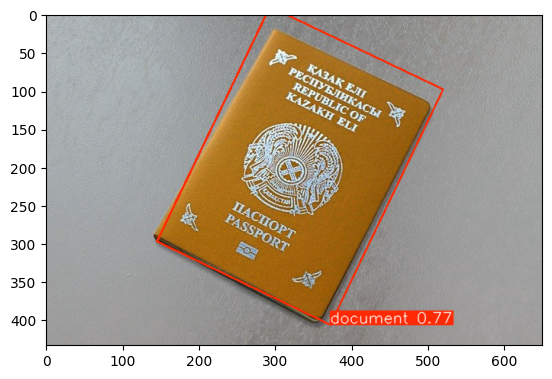

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
plt.imshow(result[0].plot())

In [52]:
import matplotlib.pyplot as plt
from PIL import Image
img_wrap = detect_page(image)
img = Image.fromarray(img_wrap)
img

NameError: name 'image' is not defined

In [66]:
from paddleocr import TextImageUnwarping
model = TextImageUnwarping(model_name="UVDoc")
output = model.predict("../../assets/images/1557807082_1515432371_pasport-rk.jpg", batch_size=1)
for res in output:
    res.print()
    res.save_to_img(save_path="./output/")
    res.save_to_json(save_path="./output/res.json")


Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Nerfmanich\.paddlex\official_models\UVDoc`.
{'res': {'input_path': '../../assets/images/1557807082_1515432371_pasport-rk.jpg', 'page_index': None, 'doctr_img': '...'}}


In [69]:
res3 = model.predict(res2[0]['doctr_img'], batch_size=1)

In [65]:
res['doctr_img']

TypeError: list indices must be integers or slices, not str

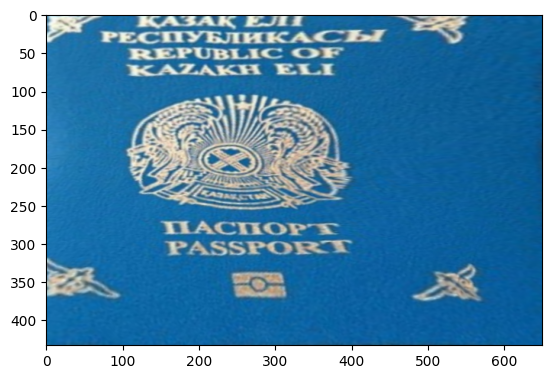

In [70]:
plt.imshow(res3[0]['doctr_img'])